In [1]:
import pandas as pd

df_clean = pd.read_excel(
    "../Data_understanding/Cleaned_Dataset.xlsx"
)

In [2]:
df_clean.shape

(4991, 11)

In [3]:
df_clean.dtypes

Record_ID                                 int64
Date_Time                        datetime64[us]
State                                       str
Sector                                      str
Consumption_MWh                         float64
Peak_Demand_MW                          float64
Generation_MWh                          float64
Electricity_Price_USD_per_MWh           float64
Renewable_Share_Pct                     float64
Weather_Index                           float64
Peak_Flag                                   str
dtype: object

In [4]:
df_clean.describe()

,Record_ID,Date_Time,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index
count,4.991000e+03,4991,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000
mean,1.061075e+05,2024-04-14 04:43:44.083350,980.060775,1021.606016,1054.037691,55.147941,30.955841,49.617552
min,1.000010e+05,2024-01-01 00:00:00,341.780000,317.010000,348.520000,-63.160000,2.000000,-16.980000
25%,1.012565e+05,2024-02-22 05:30:00,778.810000,805.325000,838.415000,49.565000,23.420000,39.395000
50%,1.025080e+05,2024-04-14 04:00:00,955.950000,990.290000,1024.520000,55.090000,31.020000,49.550000
75%,1.037635e+05,2024-06-05 06:30:00,1156.225000,1202.450000,1244.810000,60.445000,38.480000,59.775000
max,1.004887e+06,2024-07-27 07:00:00,8481.665471,9193.240659,9791.911919,471.883558,71.610000,105.920000
std,5.690509e+04,NaN,326.105081,343.204473,345.857579,12.950054,10.995724,15.094740


In [5]:
df_clean["State"].value_counts()

State
California    1525
New York      1227
Texas          904
Florida        744
Texas          591
Name: count, dtype: int64

In [6]:
df_clean["Sector"].value_counts()

Sector
Residential      1932
Industrial       1361
Commercial       1124
Commercial        554
 Residential       11
 Industrial         5
 Commercial         4
Name: count, dtype: int64

In [7]:
df_clean["Peak_Flag"].value_counts()

Peak_Flag
No     4243
Yes     748
Name: count, dtype: int64

In [8]:
df_clean["State"].unique()

<StringArray>
['California', 'Texas', 'Florida', 'Texas ', 'New York']
Length: 5, dtype: str

In [9]:
df_clean["Sector"].unique()

<StringArray>
[   'Industrial',   'Residential',    'Commercial',   'Commercial ',
 ' Residential ',  ' Industrial ',  ' Commercial ']
Length: 7, dtype: str

In [10]:
df_clean["Date_Time"].min(), df_clean["Date_Time"].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2024-07-27 07:00:00'))

In [11]:
df_clean["Date"] = df_clean["Date_Time"].dt.date

In [12]:
df_clean["Date"].value_counts().sort_index()

Date
2024-01-01    24
2024-01-02    25
2024-01-03    24
2024-01-04    23
2024-01-05    24
              ..
2024-07-23    24
2024-07-24    24
2024-07-25    24
2024-07-26    24
2024-07-27     8
Name: count, Length: 209, dtype: int64

In [13]:
df_clean.corr(numeric_only=True)

,Record_ID,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index
Record_ID,1.000000,0.002865,-0.005916,0.000974,-0.008607,0.022787,-0.008251
Consumption_MWh,0.002865,1.000000,0.653971,0.655692,0.166241,-0.012232,0.006452
Peak_Demand_MW,-0.005916,0.653971,1.000000,0.658081,0.184709,-0.007800,0.005475
Generation_MWh,0.000974,0.655692,0.658081,1.000000,0.166824,0.002574,0.010457
Electricity_Price_USD_per_MWh,-0.008607,0.166241,0.184709,0.166824,1.000000,-0.025208,-0.015684
Renewable_Share_Pct,0.022787,-0.012232,-0.007800,0.002574,-0.025208,1.000000,-0.004696
Weather_Index,-0.008251,0.006452,0.005475,0.010457,-0.015684,-0.004696,1.000000


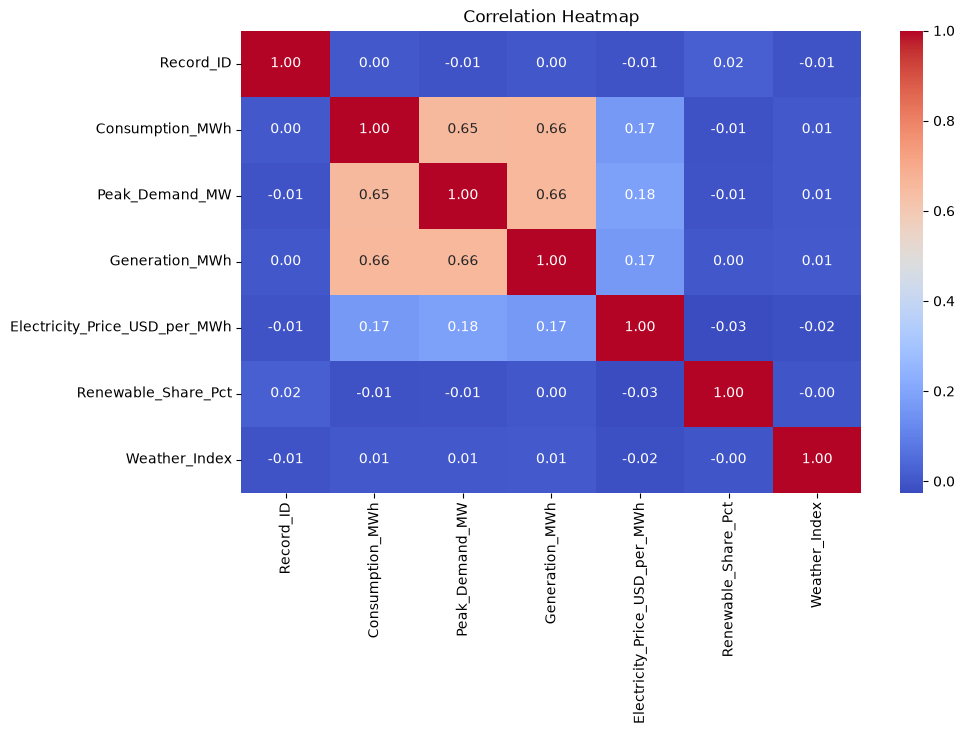

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.heatmap(
    df_clean.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

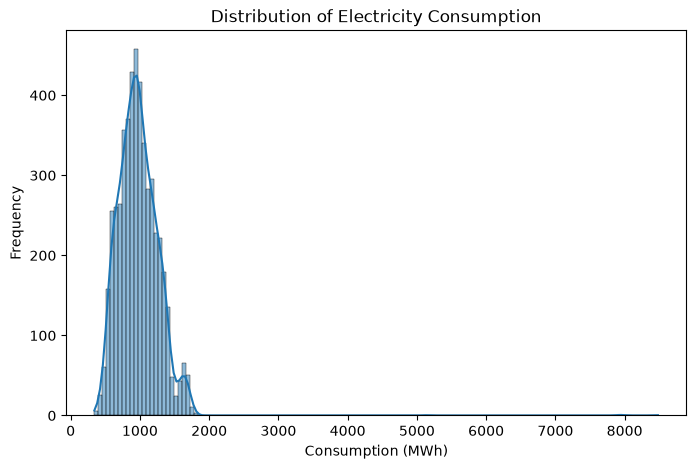

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(df_clean["Consumption_MWh"], kde=True)

plt.title("Distribution of Electricity Consumption")
plt.xlabel("Consumption (MWh)")
plt.ylabel("Frequency")
plt.show()

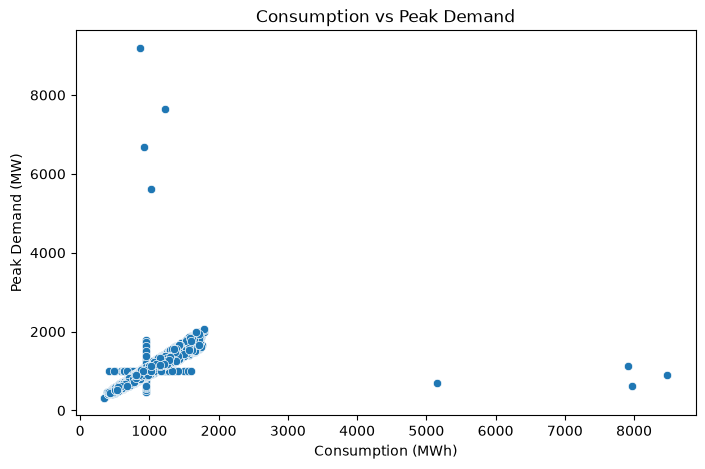

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Consumption_MWh",
    y="Peak_Demand_MW"
)

plt.title("Consumption vs Peak Demand")
plt.xlabel("Consumption (MWh)")
plt.ylabel("Peak Demand (MW)")
plt.show()

In [17]:
df_clean.groupby("State")["Consumption_MWh"].mean().sort_values(ascending=False)

State
Texas         1136.382114
Texas         1117.468964
California     967.319293
Florida        923.066751
New York       849.100369
Name: Consumption_MWh, dtype: float64

In [18]:
df_clean.groupby("Sector")["Consumption_MWh"].mean().sort_values(ascending=False)

Sector
 Industrial      1446.270000
Industrial       1170.509738
 Commercial       985.125000
Commercial        980.098756
Commercial        958.638350
Residential       858.332906
 Residential      769.484545
Name: Consumption_MWh, dtype: float64

In [19]:
df_clean.groupby("State")["Peak_Demand_MW"].mean().sort_values(ascending=False)

State
Texas         1190.369669
Texas         1168.326565
California    1015.330691
Florida        951.948763
New York       876.635094
Name: Peak_Demand_MW, dtype: float64

In [20]:
df_clean.groupby("Sector")["Peak_Demand_MW"].mean().sort_values(ascending=False)

Sector
 Industrial      1631.256000
Industrial       1214.299581
 Commercial      1052.822500
Commercial       1006.823632
Commercial        989.667870
Residential       903.272651
 Residential      794.345455
Name: Peak_Demand_MW, dtype: float64

In [21]:
df_clean.groupby(
    df_clean["Date_Time"].dt.month
)["Consumption_MWh"].mean()

Date_Time
1    983.399915
2    982.032146
3    976.755055
4    979.638933
5    981.062613
6    969.818074
7    988.884826
Name: Consumption_MWh, dtype: float64

In [22]:
df_clean.groupby(
    df_clean["Date_Time"].dt.month
)["Peak_Demand_MW"].mean()

Date_Time
1    1027.541158
2    1034.338059
3    1015.575390
4    1013.309319
5    1022.771411
6    1013.793083
7    1024.821560
Name: Peak_Demand_MW, dtype: float64

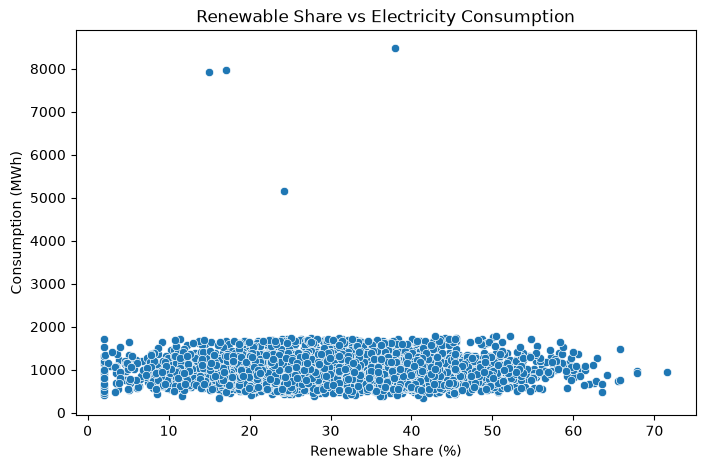

In [23]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Renewable_Share_Pct",
    y="Consumption_MWh"
)

plt.title("Renewable Share vs Electricity Consumption")
plt.xlabel("Renewable Share (%)")
plt.ylabel("Consumption (MWh)")
plt.show()

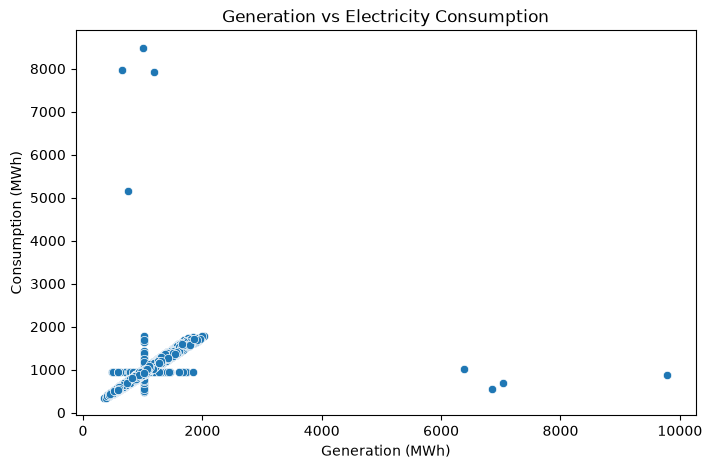

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Generation_MWh",
    y="Consumption_MWh"
)

plt.title("Generation vs Electricity Consumption")
plt.xlabel("Generation (MWh)")
plt.ylabel("Consumption (MWh)")
plt.show()

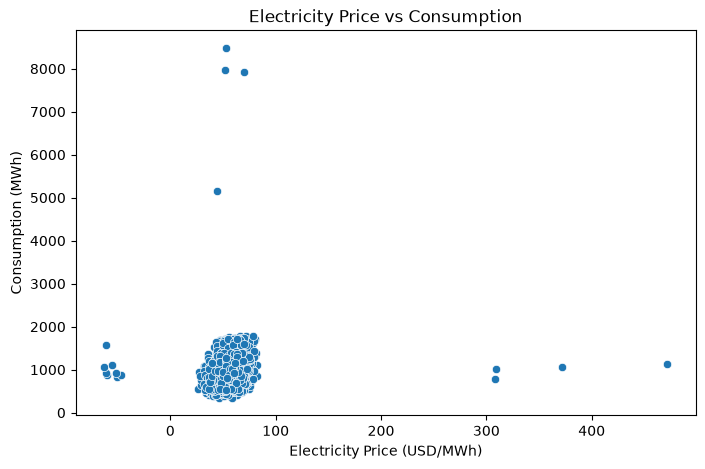

In [25]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Electricity_Price_USD_per_MWh",
    y="Consumption_MWh"
)

plt.title("Electricity Price vs Consumption")
plt.xlabel("Electricity Price (USD/MWh)")
plt.ylabel("Consumption (MWh)")
plt.show()

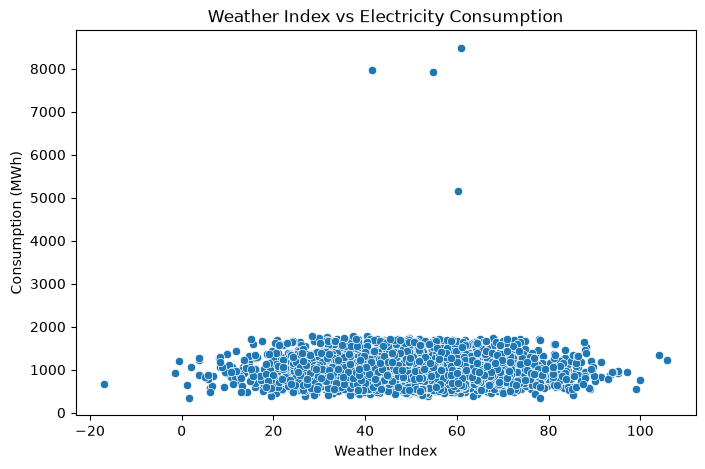

In [26]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Weather_Index",
    y="Consumption_MWh"
)

plt.title("Weather Index vs Electricity Consumption")
plt.xlabel("Weather Index")
plt.ylabel("Consumption (MWh)")
plt.show()

In [27]:
df_clean.groupby("Peak_Flag")["Consumption_MWh"].mean()

Peak_Flag
No      907.413805
Yes    1392.147797
Name: Consumption_MWh, dtype: float64

In [28]:
df_clean.groupby("Peak_Flag")["Peak_Demand_MW"].mean()

Peak_Flag
No      936.954231
Yes    1501.789866
Name: Peak_Demand_MW, dtype: float64

In [29]:
df_clean.groupby("State")["Electricity_Price_USD_per_MWh"].mean().sort_values(ascending=False)

State
Texas         56.738717
Texas         56.717394
California    55.864957
Florida       53.485287
New York      53.336985
Name: Electricity_Price_USD_per_MWh, dtype: float64

In [30]:
df_clean.groupby("Sector")["Electricity_Price_USD_per_MWh"].mean().sort_values(ascending=False)

Sector
 Industrial      65.520000
Industrial       56.276848
Commercial       55.771488
 Commercial      54.862500
Commercial       54.685108
 Residential     54.470909
Residential      54.100233
Name: Electricity_Price_USD_per_MWh, dtype: float64

In [31]:
df_clean.groupby("State")["Renewable_Share_Pct"].mean().sort_values(ascending=False)

State
Texas         31.618850
New York      31.023219
Florida       30.930887
California    30.708656
Texas         30.471049
Name: Renewable_Share_Pct, dtype: float64

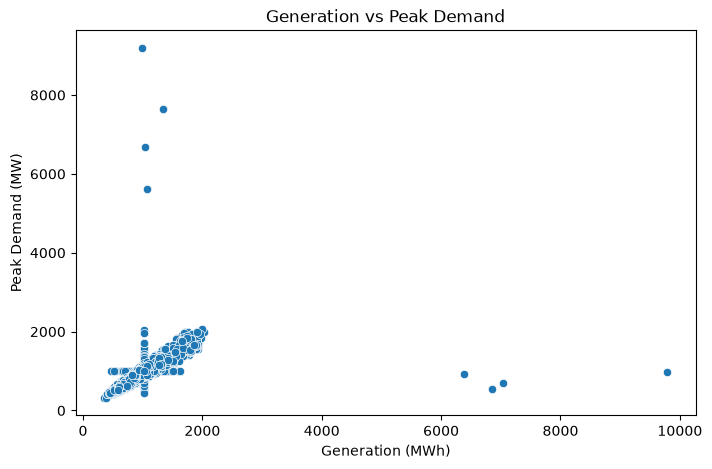

In [32]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Generation_MWh",
    y="Peak_Demand_MW"
)

plt.title("Generation vs Peak Demand")
plt.xlabel("Generation (MWh)")
plt.ylabel("Peak Demand (MW)")
plt.show()

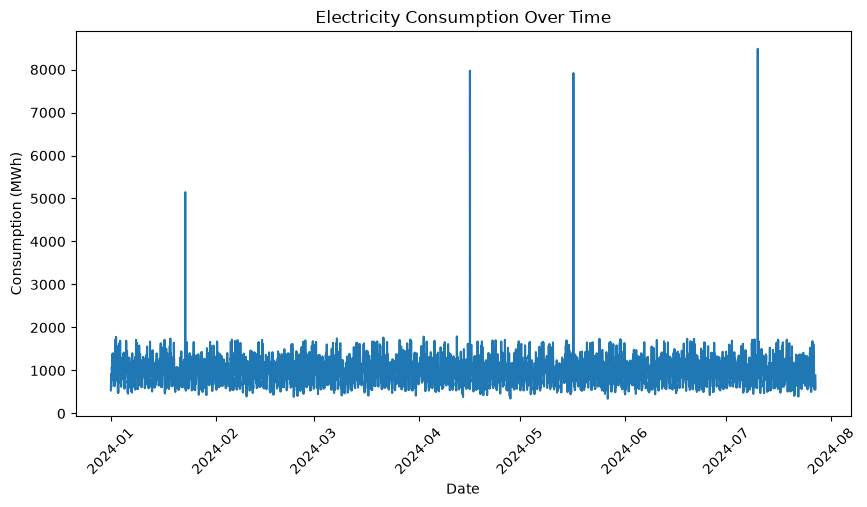

In [33]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df_clean,
    x="Date_Time",
    y="Consumption_MWh"
)

plt.title("Electricity Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Consumption (MWh)")
plt.xticks(rotation=45)
plt.show()

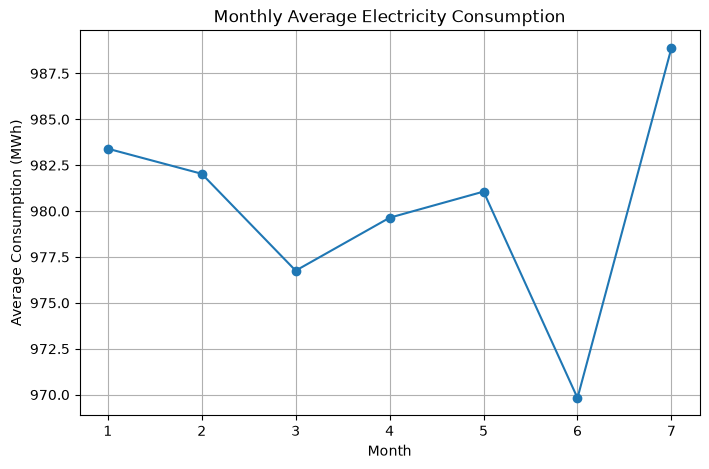

In [34]:
df_clean["Month"] = df_clean["Date_Time"].dt.month

monthly_consumption = df_clean.groupby("Month")["Consumption_MWh"].mean()

monthly_consumption.plot(kind="line", marker="o", figsize=(8, 5))

plt.title("Monthly Average Electricity Consumption")
plt.xlabel("Month")
plt.ylabel("Average Consumption (MWh)")
plt.xticks(range(1, 8))
plt.grid()
plt.show()

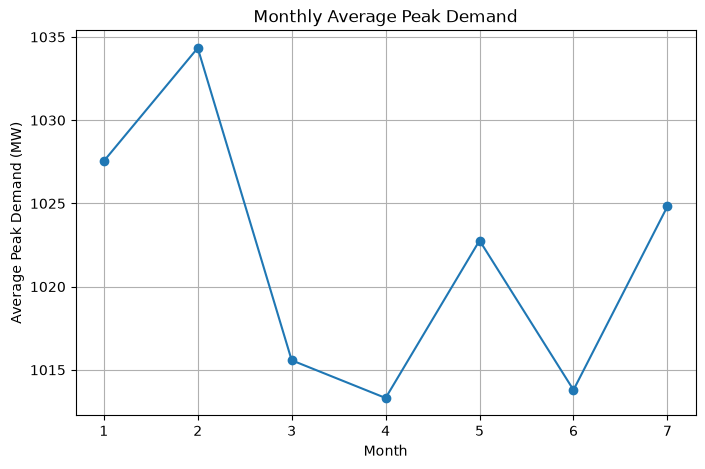

In [35]:
monthly_peak_demand = df_clean.groupby("Month")["Peak_Demand_MW"].mean()

monthly_peak_demand.plot(
    kind="line",
    marker="o",
    figsize=(8, 5)
)

plt.title("Monthly Average Peak Demand")
plt.xlabel("Month")
plt.ylabel("Average Peak Demand (MW)")
plt.xticks(range(1, 8))
plt.grid()
plt.show()

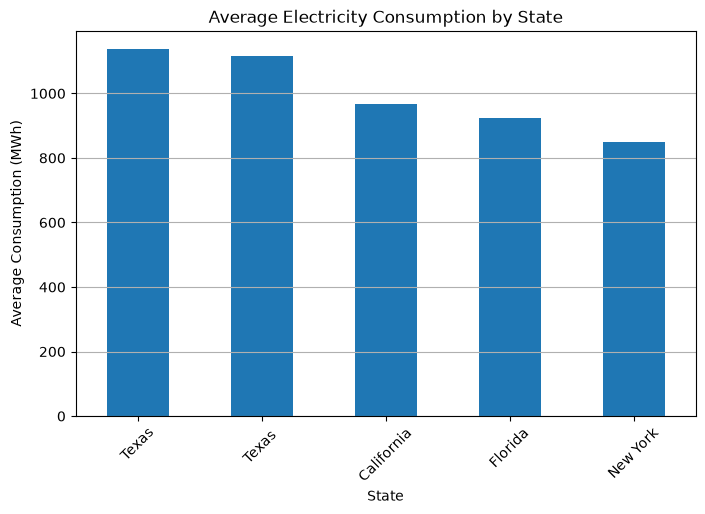

In [36]:
state_consumption = df_clean.groupby("State")["Consumption_MWh"].mean().sort_values(ascending=False)

state_consumption.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Electricity Consumption by State")
plt.xlabel("State")
plt.ylabel("Average Consumption (MWh)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

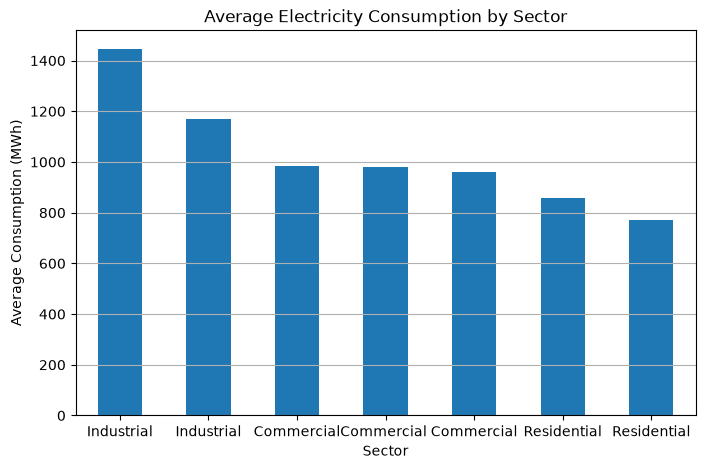

In [37]:
sector_consumption = df_clean.groupby("Sector")["Consumption_MWh"].mean().sort_values(ascending=False)

sector_consumption.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Electricity Consumption by Sector")
plt.xlabel("Sector")
plt.ylabel("Average Consumption (MWh)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

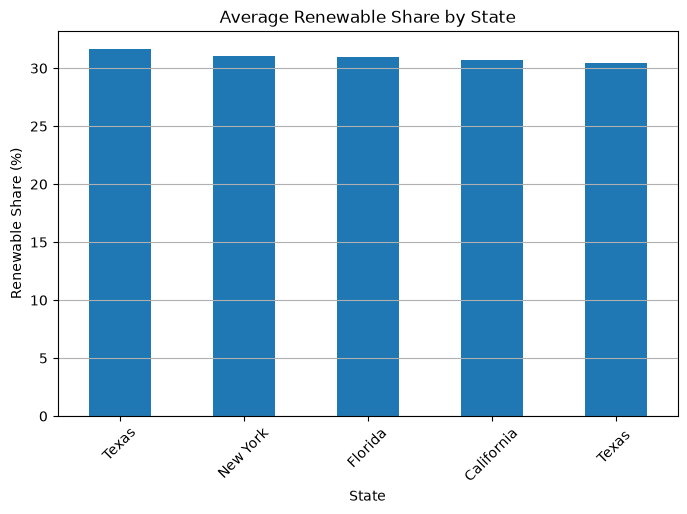

In [38]:
state_renewable = df_clean.groupby("State")["Renewable_Share_Pct"].mean().sort_values(ascending=False)

state_renewable.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Renewable Share by State")
plt.xlabel("State")
plt.ylabel("Renewable Share (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

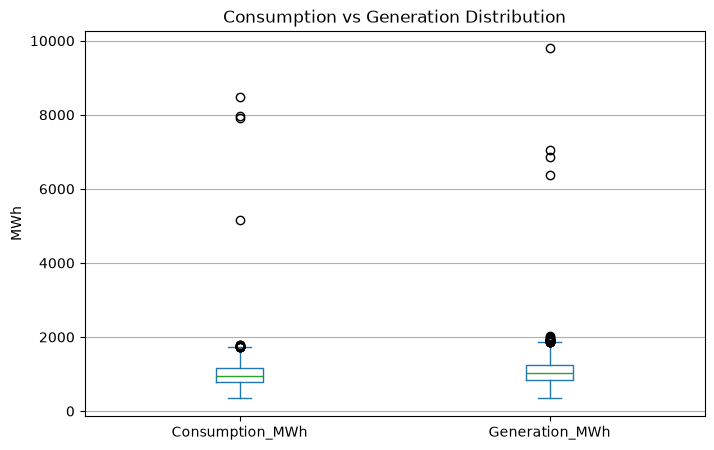

In [39]:
df_clean[[
    "Consumption_MWh",
    "Generation_MWh"
]].plot(
    kind="box",
    figsize=(8, 5)
)

plt.title("Consumption vs Generation Distribution")
plt.ylabel("MWh")
plt.grid(axis="y")
plt.show()

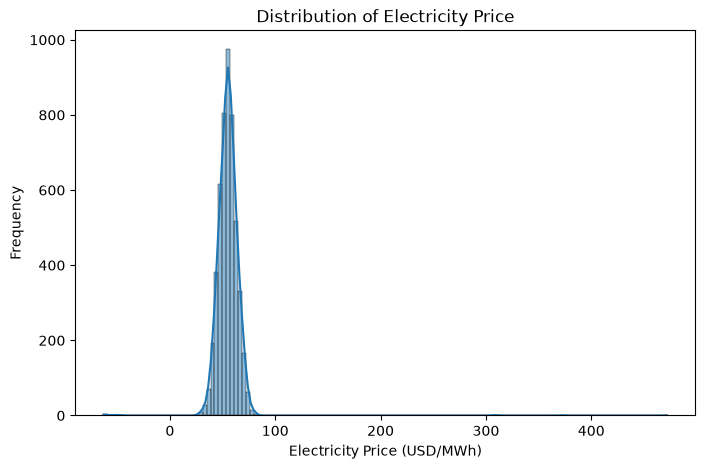

In [40]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["Electricity_Price_USD_per_MWh"],
    kde=True
)

plt.title("Distribution of Electricity Price")
plt.xlabel("Electricity Price (USD/MWh)")
plt.ylabel("Frequency")
plt.show()

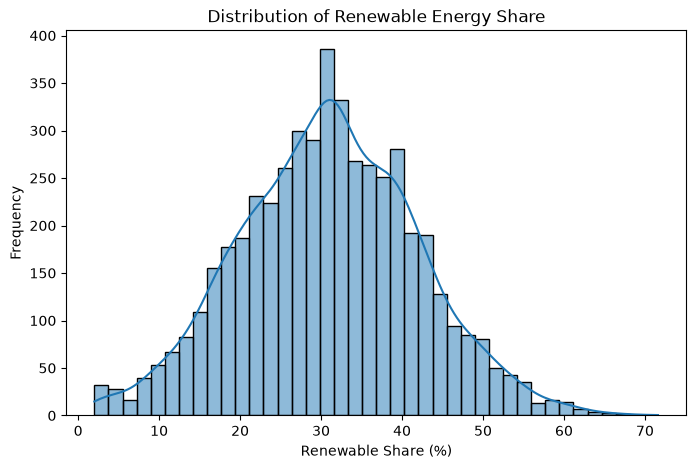

In [41]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["Renewable_Share_Pct"],
    kde=True
)

plt.title("Distribution of Renewable Energy Share")
plt.xlabel("Renewable Share (%)")
plt.ylabel("Frequency")
plt.show()

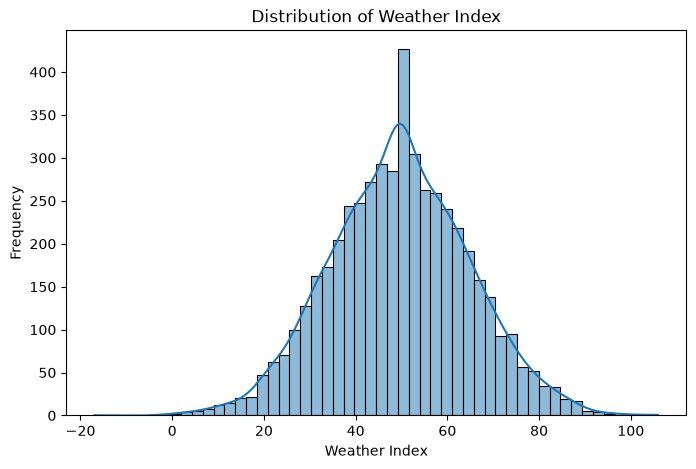

In [42]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["Weather_Index"],
    kde=True
)

plt.title("Distribution of Weather Index")
plt.xlabel("Weather Index")
plt.ylabel("Frequency")
plt.show()

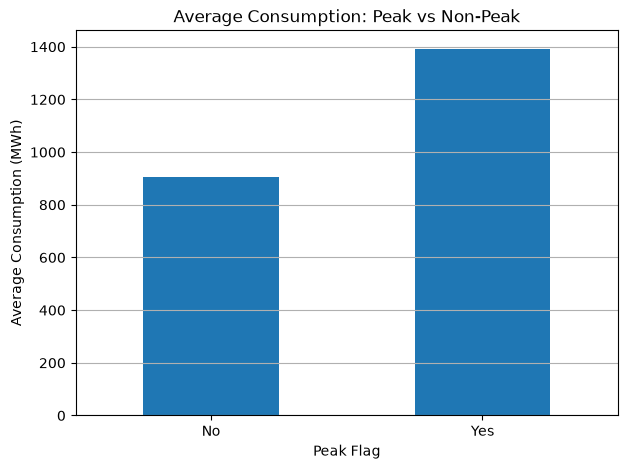

In [43]:
peak_consumption = df_clean.groupby("Peak_Flag")["Consumption_MWh"].mean()

peak_consumption.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Consumption: Peak vs Non-Peak")
plt.xlabel("Peak Flag")
plt.ylabel("Average Consumption (MWh)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

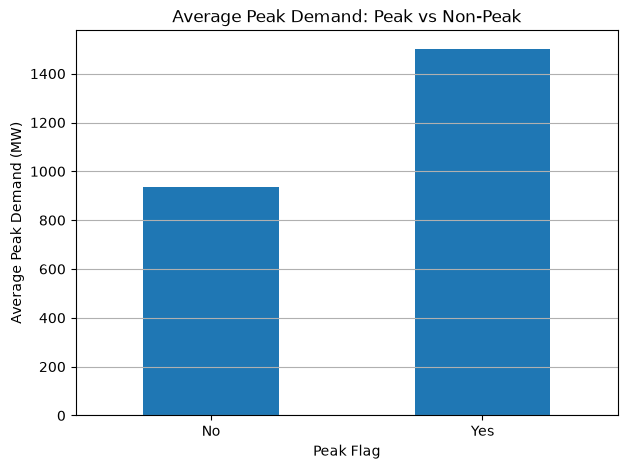

In [44]:
peak_demand = df_clean.groupby("Peak_Flag")["Peak_Demand_MW"].mean()

peak_demand.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Peak Demand: Peak vs Non-Peak")
plt.xlabel("Peak Flag")
plt.ylabel("Average Peak Demand (MW)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

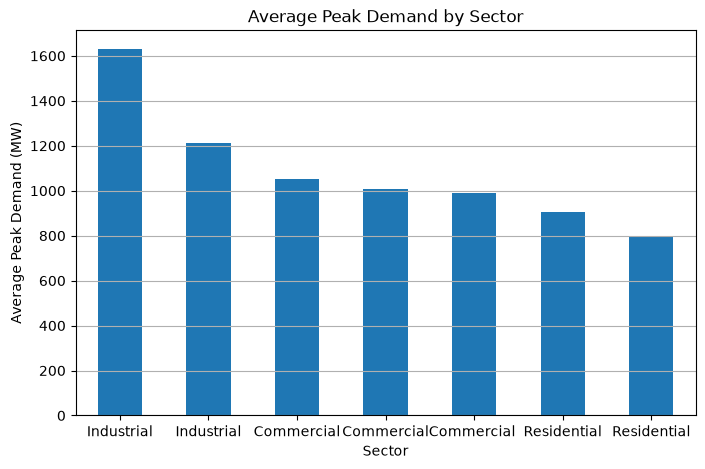

In [45]:
sector_peak = df_clean.groupby("Sector")["Peak_Demand_MW"].mean().sort_values(ascending=False)

sector_peak.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Peak Demand by Sector")
plt.xlabel("Sector")
plt.ylabel("Average Peak Demand (MW)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

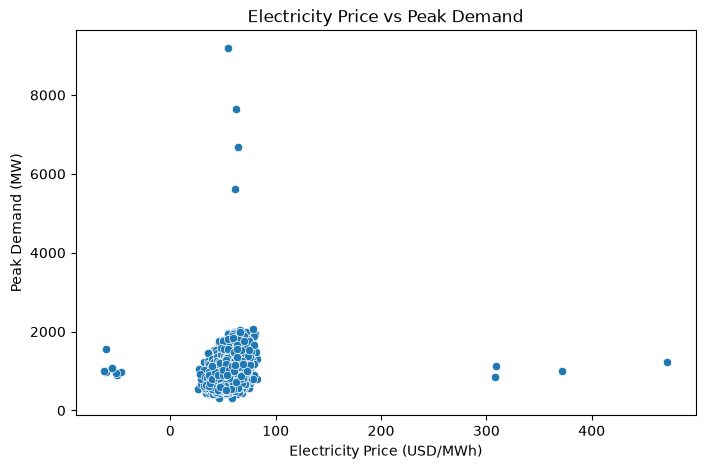

In [46]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Electricity_Price_USD_per_MWh",
    y="Peak_Demand_MW"
)

plt.title("Electricity Price vs Peak Demand")
plt.xlabel("Electricity Price (USD/MWh)")
plt.ylabel("Peak Demand (MW)")
plt.show()

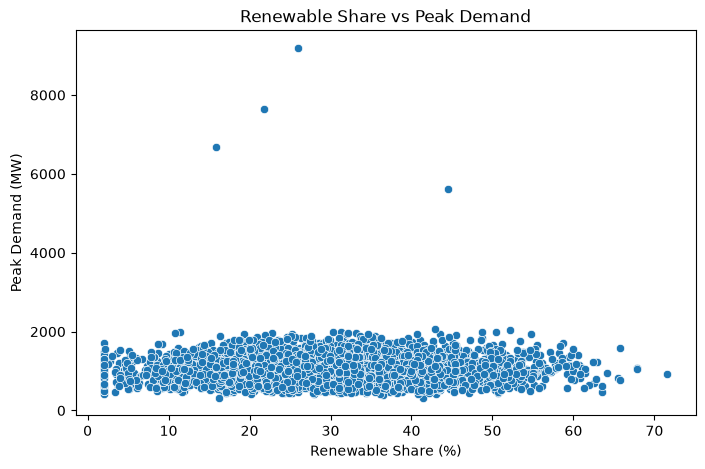

In [47]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Renewable_Share_Pct",
    y="Peak_Demand_MW"
)

plt.title("Renewable Share vs Peak Demand")
plt.xlabel("Renewable Share (%)")
plt.ylabel("Peak Demand (MW)")
plt.show()

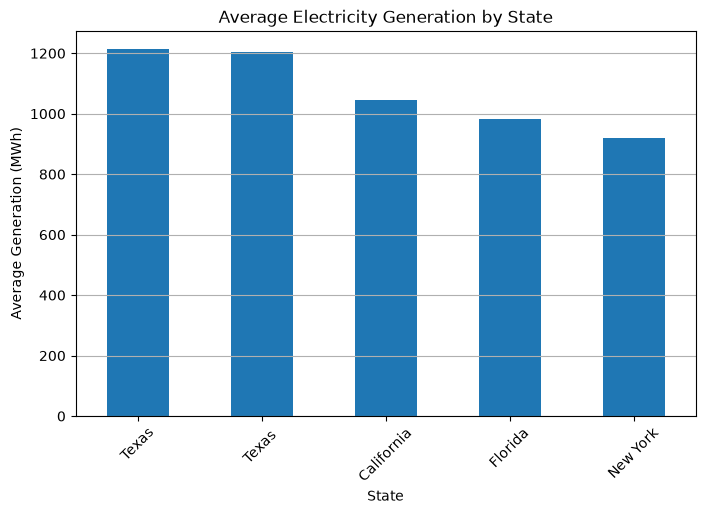

In [48]:
state_generation = df_clean.groupby("State")["Generation_MWh"].mean().sort_values(ascending=False)

state_generation.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Electricity Generation by State")
plt.xlabel("State")
plt.ylabel("Average Generation (MWh)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

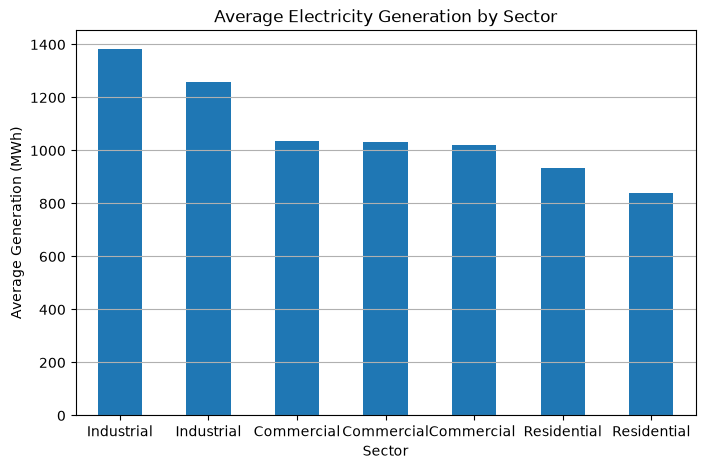

In [49]:
sector_generation = df_clean.groupby("Sector")["Generation_MWh"].mean().sort_values(ascending=False)

sector_generation.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Electricity Generation by Sector")
plt.xlabel("Sector")
plt.ylabel("Average Generation (MWh)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

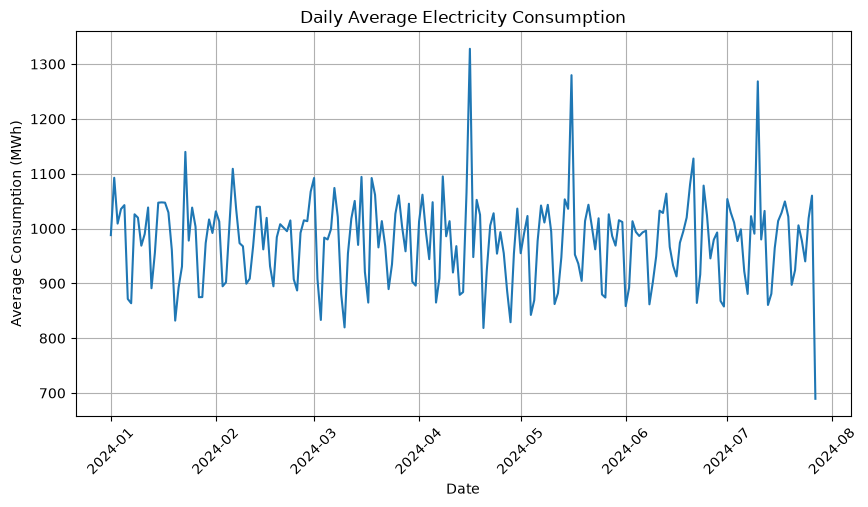

In [50]:
daily_consumption = df_clean.groupby("Date")["Consumption_MWh"].mean()

daily_consumption.plot(
    kind="line",
    figsize=(10, 5)
)

plt.title("Daily Average Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Average Consumption (MWh)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

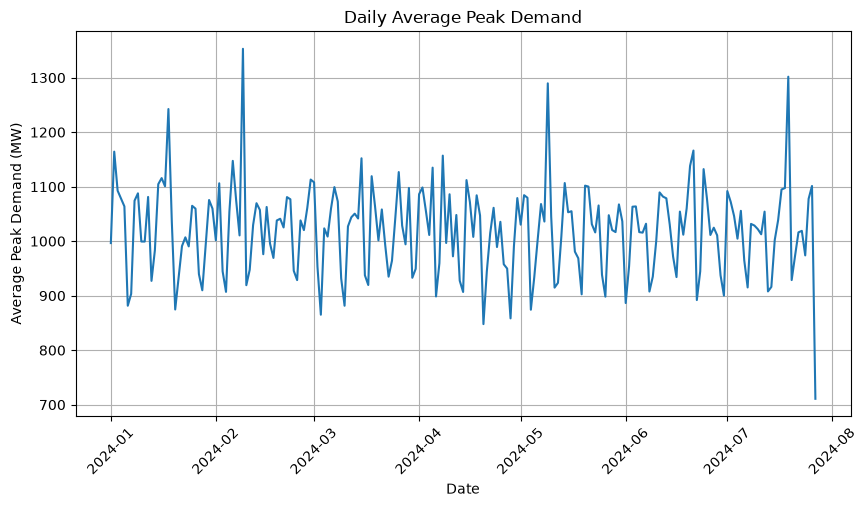

In [51]:
daily_peak_demand = df_clean.groupby("Date")["Peak_Demand_MW"].mean()

daily_peak_demand.plot(
    kind="line",
    figsize=(10, 5)
)

plt.title("Daily Average Peak Demand")
plt.xlabel("Date")
plt.ylabel("Average Peak Demand (MW)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

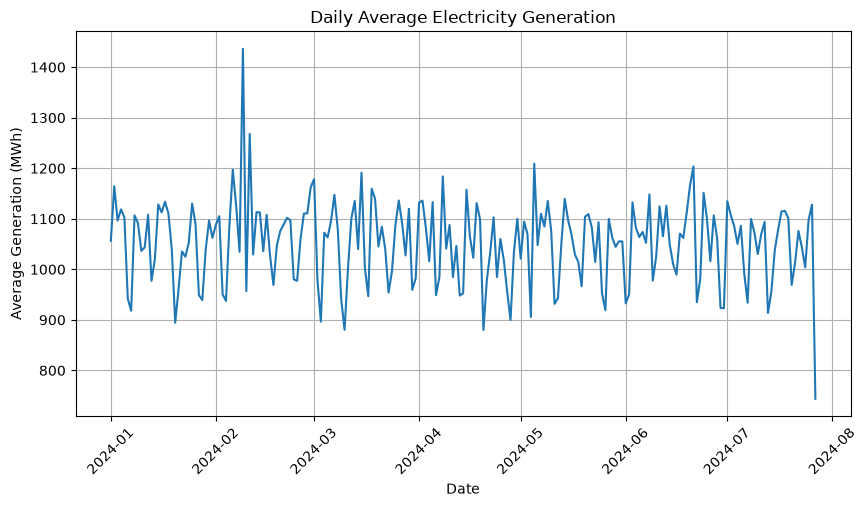

In [52]:
daily_generation = df_clean.groupby("Date")["Generation_MWh"].mean()

daily_generation.plot(
    kind="line",
    figsize=(10, 5)
)

plt.title("Daily Average Electricity Generation")
plt.xlabel("Date")
plt.ylabel("Average Generation (MWh)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

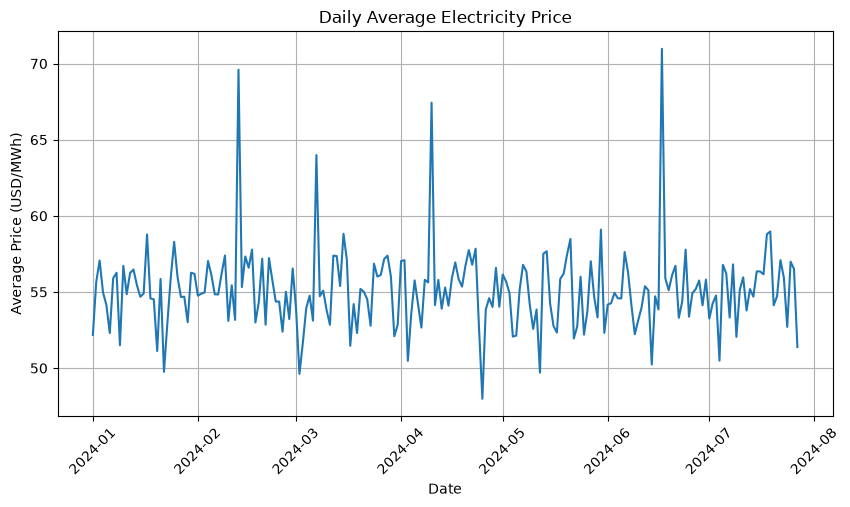

In [53]:
daily_price = df_clean.groupby("Date")["Electricity_Price_USD_per_MWh"].mean()

daily_price.plot(
    kind="line",
    figsize=(10, 5)
)

plt.title("Daily Average Electricity Price")
plt.xlabel("Date")
plt.ylabel("Average Price (USD/MWh)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

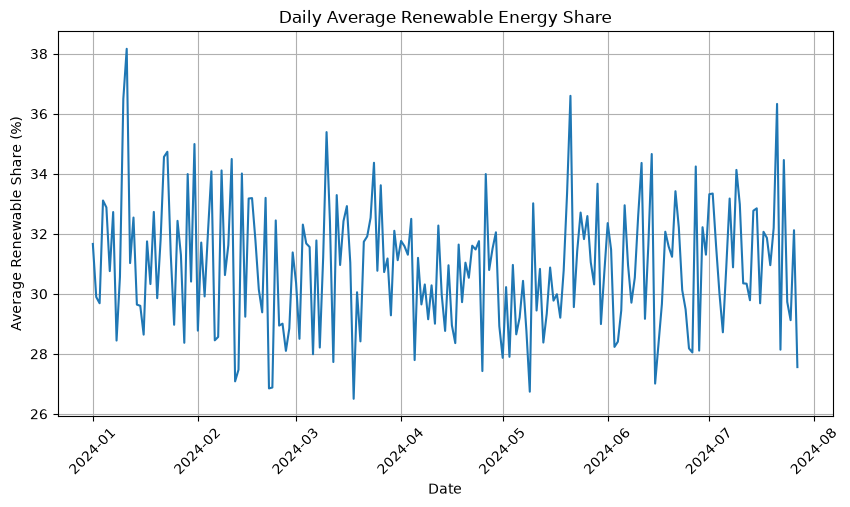

In [54]:
daily_renewable = df_clean.groupby("Date")["Renewable_Share_Pct"].mean()

daily_renewable.plot(
    kind="line",
    figsize=(10, 5)
)

plt.title("Daily Average Renewable Energy Share")
plt.xlabel("Date")
plt.ylabel("Average Renewable Share (%)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

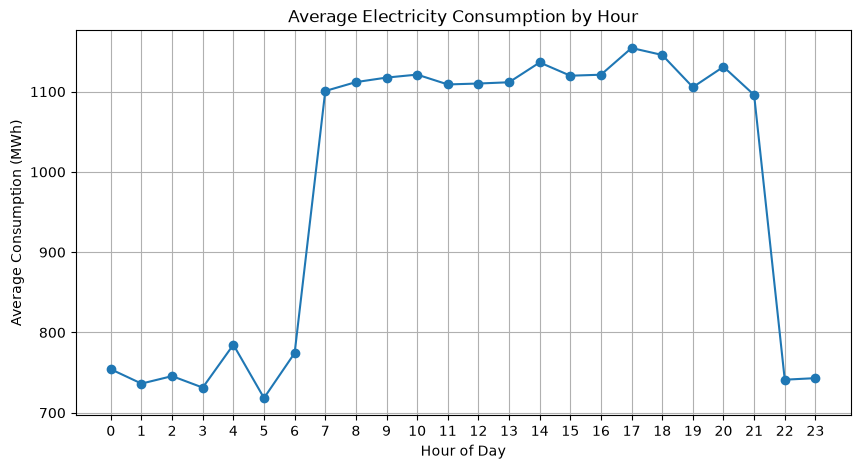

In [55]:
hourly_consumption = df_clean.groupby(
    df_clean["Date_Time"].dt.hour
)["Consumption_MWh"].mean()

hourly_consumption.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Average Electricity Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (MWh)")
plt.xticks(range(24))
plt.grid()
plt.show()

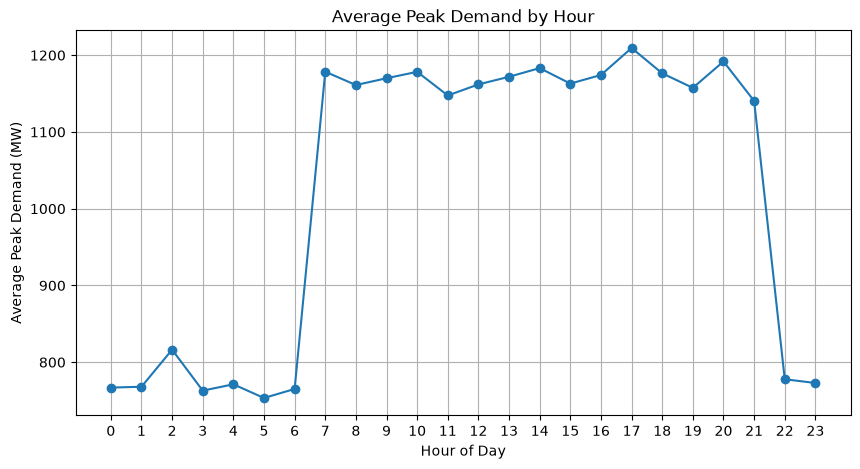

In [56]:
hourly_peak_demand = df_clean.groupby(
    df_clean["Date_Time"].dt.hour
)["Peak_Demand_MW"].mean()

hourly_peak_demand.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Average Peak Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Peak Demand (MW)")
plt.xticks(range(24))
plt.grid()
plt.show()

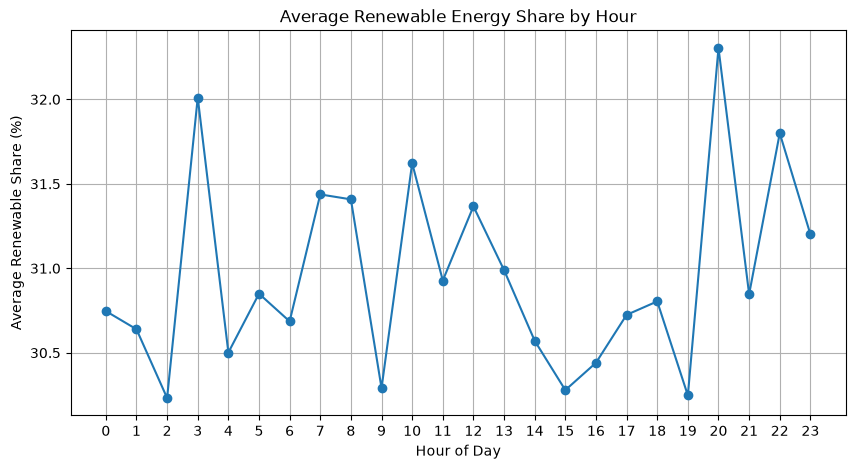

In [57]:
hourly_renewable = df_clean.groupby(
    df_clean["Date_Time"].dt.hour
)["Renewable_Share_Pct"].mean()

hourly_renewable.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Average Renewable Energy Share by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Renewable Share (%)")
plt.xticks(range(24))
plt.grid()
plt.show()

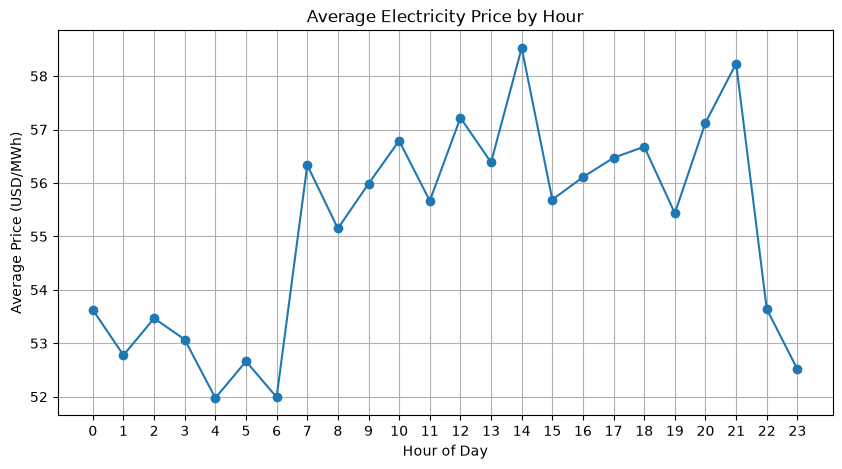

In [58]:
hourly_price = df_clean.groupby(
    df_clean["Date_Time"].dt.hour
)["Electricity_Price_USD_per_MWh"].mean()

hourly_price.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Average Electricity Price by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Price (USD/MWh)")
plt.xticks(range(24))
plt.grid()
plt.show()

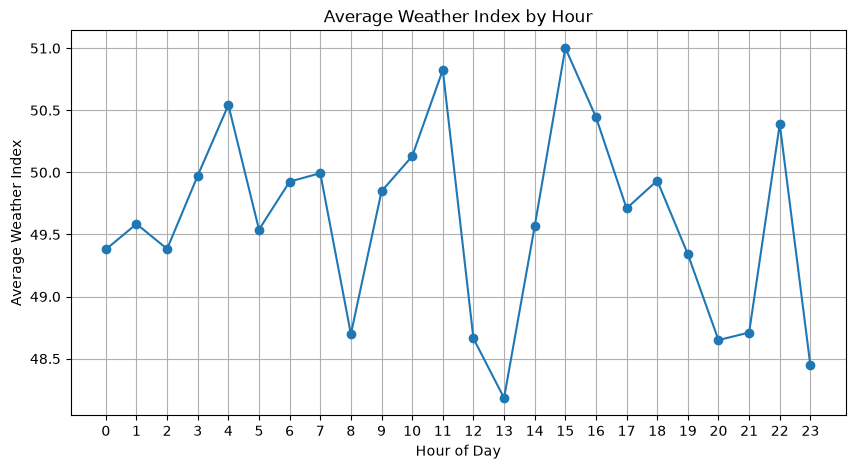

In [59]:
hourly_weather = df_clean.groupby(
    df_clean["Date_Time"].dt.hour
)["Weather_Index"].mean()

hourly_weather.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Average Weather Index by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Weather Index")
plt.xticks(range(24))
plt.grid()
plt.show()

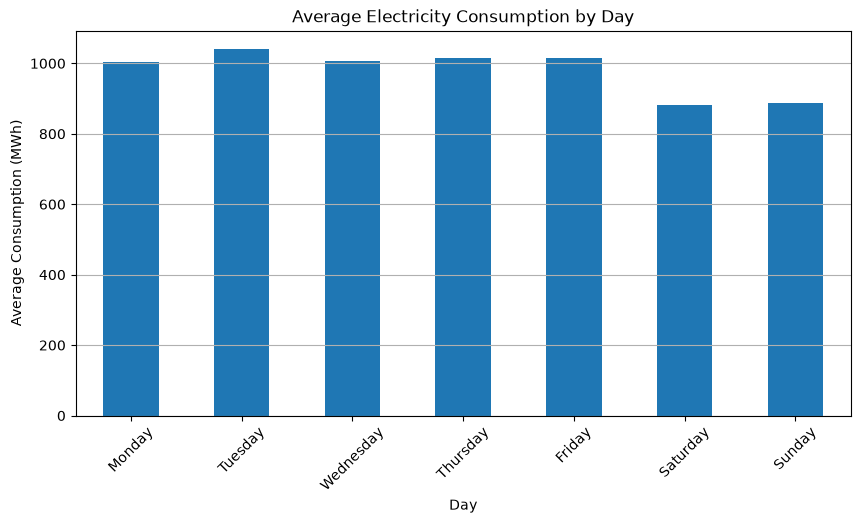

In [60]:
df_clean["Day_Name"] = df_clean["Date_Time"].dt.day_name()

day_consumption = df_clean.groupby(
    "Day_Name"
)["Consumption_MWh"].mean()

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_consumption = day_consumption.reindex(day_order)

day_consumption.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Electricity Consumption by Day")
plt.xlabel("Day")
plt.ylabel("Average Consumption (MWh)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

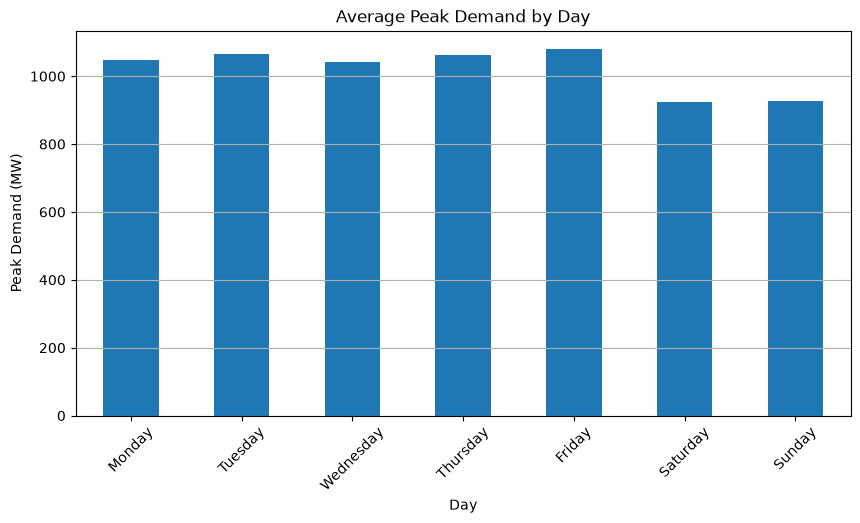

In [61]:
day_peak = df_clean.groupby("Day_Name")["Peak_Demand_MW"].mean().reindex(day_order)

day_peak.plot(kind="bar", figsize=(10,5))
plt.title("Average Peak Demand by Day")
plt.xlabel("Day")
plt.ylabel("Peak Demand (MW)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

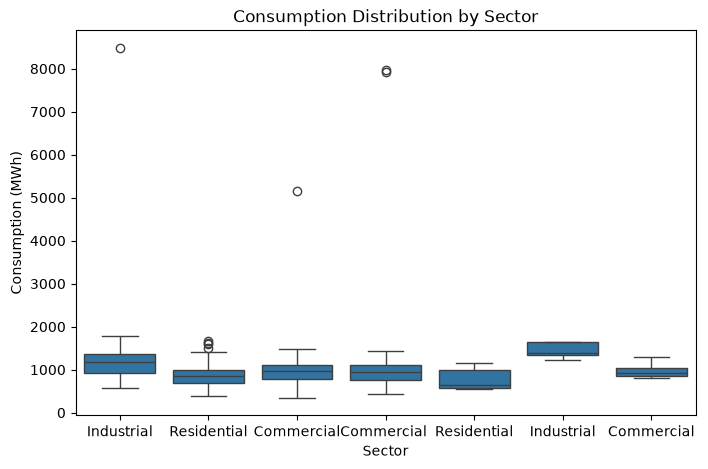

In [62]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Sector",
    y="Consumption_MWh"
)

plt.title("Consumption Distribution by Sector")
plt.xlabel("Sector")
plt.ylabel("Consumption (MWh)")
plt.show()

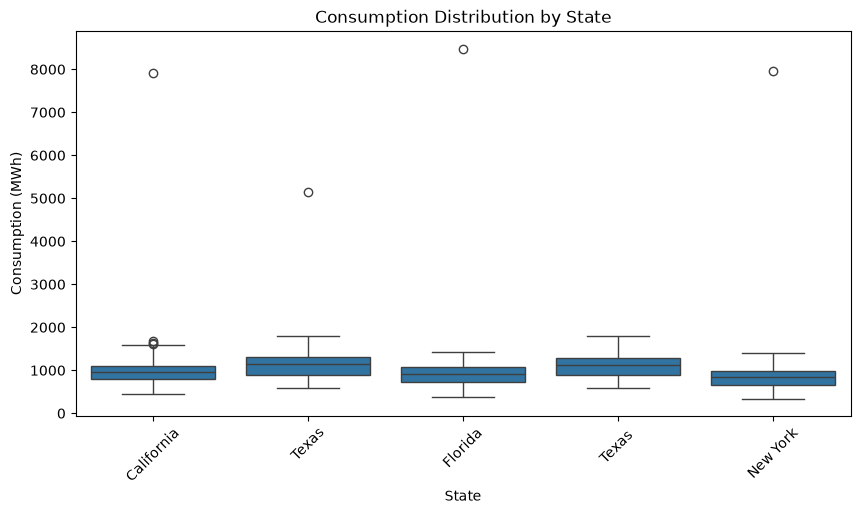

In [63]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_clean,
    x="State",
    y="Consumption_MWh"
)

plt.title("Consumption Distribution by State")
plt.xlabel("State")
plt.ylabel("Consumption (MWh)")
plt.xticks(rotation=45)
plt.show()

In [64]:
df_clean.groupby("Sector")["Renewable_Share_Pct"].mean().sort_values(ascending=False)

Sector
 Commercial      35.972500
Commercial       31.148986
Commercial       31.013303
Industrial       30.920492
Residential      30.876988
 Residential     27.091818
 Industrial      25.748000
Name: Renewable_Share_Pct, dtype: float64

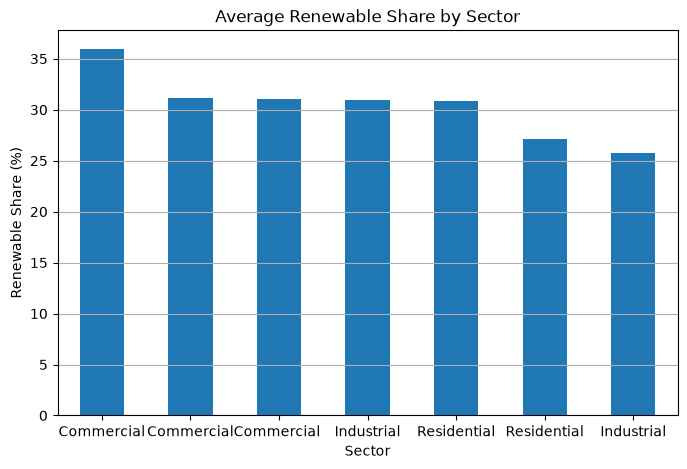

In [65]:
sector_renewable = df_clean.groupby("Sector")["Renewable_Share_Pct"].mean().sort_values(ascending=False)

sector_renewable.plot(kind="bar", figsize=(8,5))

plt.title("Average Renewable Share by Sector")
plt.xlabel("Sector")
plt.ylabel("Renewable Share (%)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [66]:
df_clean["Generation_Consumption_Ratio"] = (
    df_clean["Generation_MWh"] / df_clean["Consumption_MWh"]
)

df_clean["Generation_Consumption_Ratio"].describe()

count    4991.000000
mean        1.084165
std         0.276137
min         0.082987
25%         1.037425
50%         1.076107
75%         1.113467
max        12.656001
Name: Generation_Consumption_Ratio, dtype: float64

In [67]:
df_clean.nlargest(10, "Consumption_MWh")[
    ["Date_Time", "State", "Sector", "Consumption_MWh"]
]

,Date_Time,State,Sector,Consumption_MWh
2670,2024-07-10 06:00:00,Florida,Industrial,8481.665471
3329,2024-04-16 04:00:00,New York,Commercial,7971.614985
1529,2024-05-16 18:00:00,California,Commercial,7916.366386
2260,2024-01-23 00:00:00,Texas,Commercial,5147.613509
4673,2024-04-12 07:00:00,Texas,Industrial,1792.230000
1225,2024-04-02 12:00:00,Texas,Industrial,1787.710000
3549,2024-01-02 13:00:00,Texas,Industrial,1782.220000
80,2024-03-21 14:00:00,Texas,Industrial,1765.760000
4203,2024-03-07 20:00:00,Texas,Industrial,1745.120000
375,2024-01-18 14:00:00,Texas,Industrial,1742.500000


In [68]:
df_clean.nlargest(10, "Peak_Demand_MW")[
    ["Date_Time", "State", "Sector", "Peak_Demand_MW"]
]

,Date_Time,State,Sector,Peak_Demand_MW
3798,2024-02-09 02:00:00,Texas,Residential,9193.240659
1901,2024-07-19 18:00:00,California,Commercial,7653.801250
2764,2024-05-09 07:00:00,California,Residential,6683.321506
2651,2024-01-18 13:00:00,California,Commercial,5616.810724
4673,2024-04-12 07:00:00,Texas,Industrial,2063.950000
3549,2024-01-02 13:00:00,Texas,Industrial,2051.090000
1085,2024-01-02 07:00:00,Texas,Industrial,1997.220000
630,2024-07-02 15:00:00,Texas,Industrial,1994.070000
3986,2024-06-10 10:00:00,Texas,Industrial,1987.630000
1225,2024-04-02 12:00:00,Texas,Industrial,1983.410000


In [69]:
df_clean.nlargest(10, "Generation_MWh")[
    ["Date_Time", "State", "Sector", "Generation_MWh"]
]

,Date_Time,State,Sector,Generation_MWh
3423,2024-02-09 11:00:00,New York,Residential,9791.911919
4035,2024-02-11 03:00:00,New York,Industrial,7043.174532
1394,2024-05-05 01:00:00,California,Residential,6848.921358
698,2024-06-08 13:00:00,California,Commercial,6378.977833
1225,2024-04-02 12:00:00,Texas,Industrial,2028.140000
4673,2024-04-12 07:00:00,Texas,Industrial,1998.370000
2130,2024-06-19 09:00:00,Texas,Industrial,1969.780000
4778,2024-03-26 09:00:00,Texas,Industrial,1955.340000
4339,2024-06-21 10:00:00,Texas,Industrial,1931.900000
848,2024-05-30 20:00:00,Texas,Industrial,1928.050000


In [70]:
df_clean.corr(numeric_only=True)["Peak_Demand_MW"].sort_values(ascending=False)

Peak_Demand_MW                   1.000000
Generation_MWh                   0.658081
Consumption_MWh                  0.653971
Electricity_Price_USD_per_MWh    0.184709
Weather_Index                    0.005475
Record_ID                       -0.005916
Renewable_Share_Pct             -0.007800
Month                           -0.009056
Generation_Consumption_Ratio    -0.022612
Name: Peak_Demand_MW, dtype: float64

Date_Time sort

In [71]:
df_clean = df_clean.sort_values("Date_Time")

df_clean.head()

,Record_ID,Date_Time,State,Sector,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index,Peak_Flag,Date,Month,Day_Name,Generation_Consumption_Ratio
1935,100001,2024-01-01 00:00:00,New York,Commercial,536.98,548.24,591.31,57.96,24.54,63.34,No,2024-01-01,1,Monday,1.101177
3287,100002,2024-01-01 01:00:00,New York,Industrial,711.44,651.59,742.86,47.25,16.44,64.30,No,2024-01-01,1,Monday,1.044164
3581,100003,2024-01-01 02:00:00,Texas,Commercial,886.27,943.58,956.56,52.56,49.76,60.19,No,2024-01-01,1,Monday,1.079310
4241,100004,2024-01-01 03:00:00,Florida,Commercial,612.50,680.95,689.68,47.28,41.15,44.96,No,2024-01-01,1,Monday,1.126008
4647,100005,2024-01-01 04:00:00,Texas,Commercial,933.32,948.00,942.87,43.83,41.12,51.56,No,2024-01-01,1,Monday,1.010232


In [72]:
df_ts = df_clean.set_index("Date_Time")

df_ts.head()

,Record_ID,State,Sector,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index,Peak_Flag,Date,Month,Day_Name,Generation_Consumption_Ratio
Date_Time,,,,,,,,,,,,,,
2024-01-01 00:00:00,100001,New York,Commercial,536.98,548.24,591.31,57.96,24.54,63.34,No,2024-01-01,1,Monday,1.101177
2024-01-01 01:00:00,100002,New York,Industrial,711.44,651.59,742.86,47.25,16.44,64.30,No,2024-01-01,1,Monday,1.044164
2024-01-01 02:00:00,100003,Texas,Commercial,886.27,943.58,956.56,52.56,49.76,60.19,No,2024-01-01,1,Monday,1.079310
2024-01-01 03:00:00,100004,Florida,Commercial,612.50,680.95,689.68,47.28,41.15,44.96,No,2024-01-01,1,Monday,1.126008
2024-01-01 04:00:00,100005,Texas,Commercial,933.32,948.00,942.87,43.83,41.12,51.56,No,2024-01-01,1,Monday,1.010232


Daily Average Data

In [73]:
daily_data = df_ts.resample("D")[[
    "Consumption_MWh",
    "Peak_Demand_MW"
]].mean()

daily_data.head()

,Consumption_MWh,Peak_Demand_MW
Date_Time,,
2024-01-01,987.953750,996.522083
2024-01-02,1092.538557,1164.275200
2024-01-03,1009.025417,1092.723750
2024-01-04,1035.547391,1078.490870
2024-01-05,1042.681667,1063.859583


Daily Consumption Trend

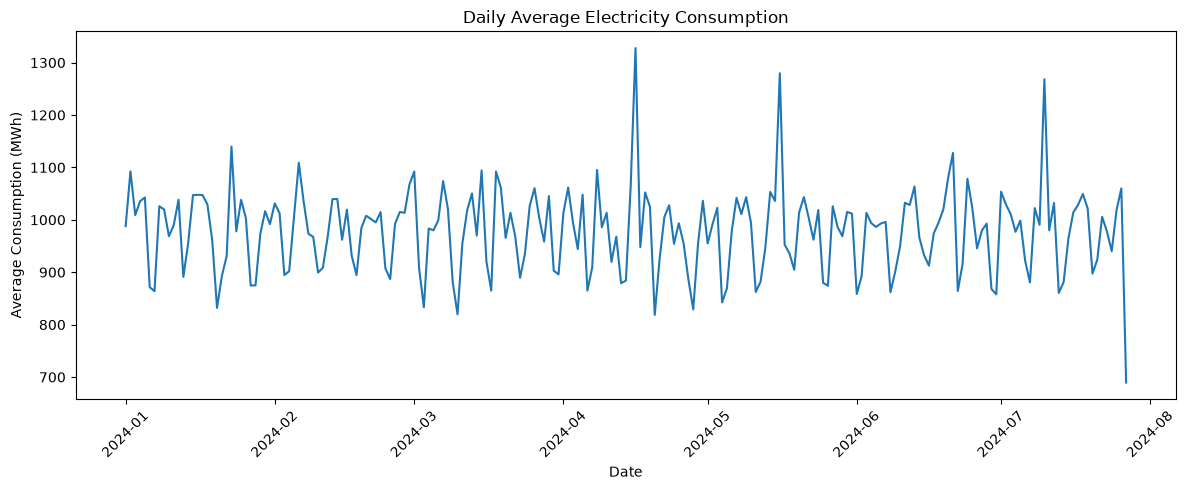

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    daily_data.index,
    daily_data["Consumption_MWh"]
)

plt.title("Daily Average Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Average Consumption (MWh)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Daily Peak Demand Trend

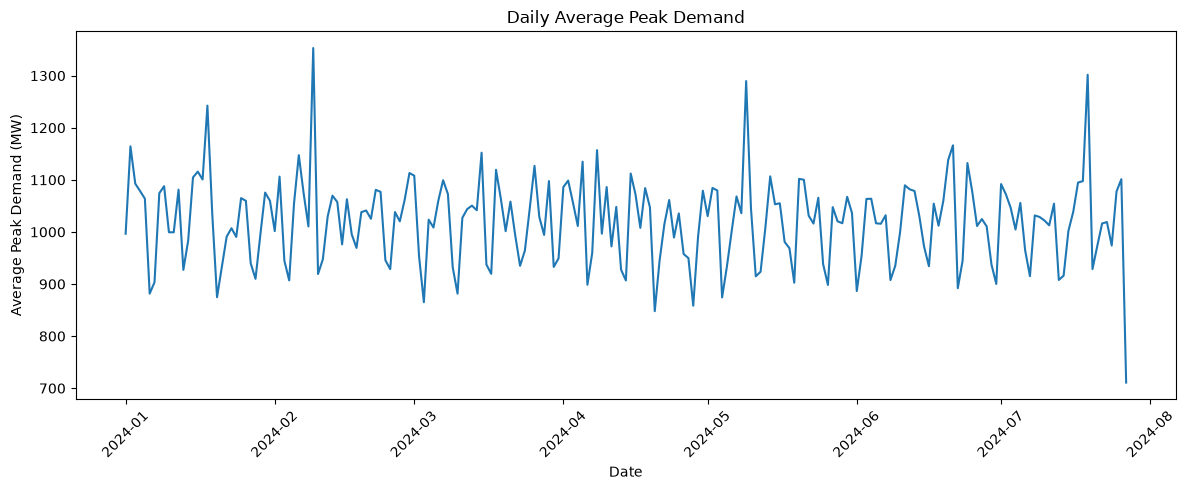

In [75]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_data.index,
    daily_data["Peak_Demand_MW"]
)

plt.title("Daily Average Peak Demand")
plt.xlabel("Date")
plt.ylabel("Average Peak Demand (MW)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Consumption vs Peak Demand Trend

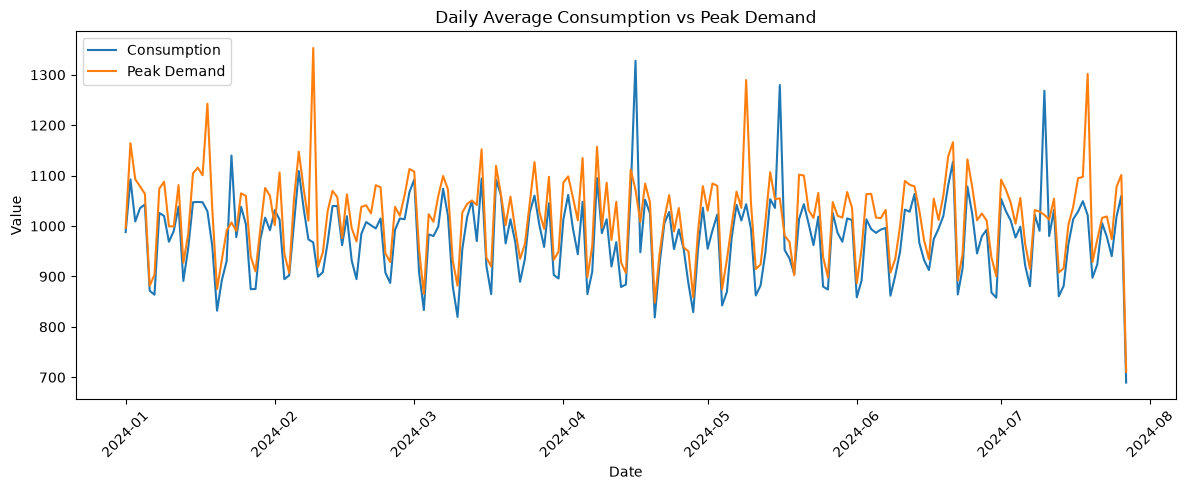

In [76]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_data.index,
    daily_data["Consumption_MWh"],
    label="Consumption"
)

plt.plot(
    daily_data.index,
    daily_data["Peak_Demand_MW"],
    label="Peak Demand"
)

plt.title("Daily Average Consumption vs Peak Demand")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Hourly Pattern Analysis

In [77]:
hourly_data = df_ts.groupby(
    df_ts.index.hour
)[[
    "Consumption_MWh",
    "Peak_Demand_MW"
]].mean()

hourly_data.head()

,Consumption_MWh,Peak_Demand_MW
Date_Time,,
0,754.220820,766.957667
1,736.335171,768.064098
2,745.664783,816.331356
3,731.358995,762.990335
4,784.779589,771.239324


Hourly Consumption & Peak Demand Graph

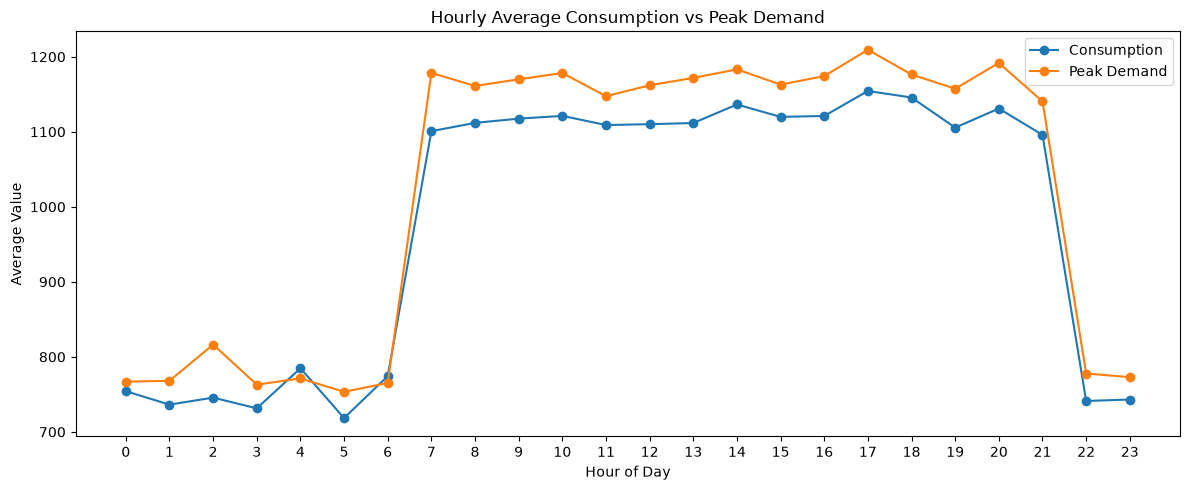

In [78]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_data.index,
    hourly_data["Consumption_MWh"],
    marker="o",
    label="Consumption"
)

plt.plot(
    hourly_data.index,
    hourly_data["Peak_Demand_MW"],
    marker="o",
    label="Peak Demand"
)

plt.title("Hourly Average Consumption vs Peak Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Average Value")
plt.xticks(range(24))
plt.legend()

plt.tight_layout()
plt.show()

Monthly Average Trend

In [79]:
monthly_data = df_ts.resample("ME")[[
    "Consumption_MWh",
    "Peak_Demand_MW"
]].mean()

monthly_data

,Consumption_MWh,Peak_Demand_MW
Date_Time,,
2024-01-31,983.399915,1027.541158
2024-02-29,982.032146,1034.338059
2024-03-31,976.755055,1015.575390
2024-04-30,979.638933,1013.309319
2024-05-31,981.062613,1022.771411
2024-06-30,969.818074,1013.793083
2024-07-31,988.884826,1024.821560


Monthly Trend Graph

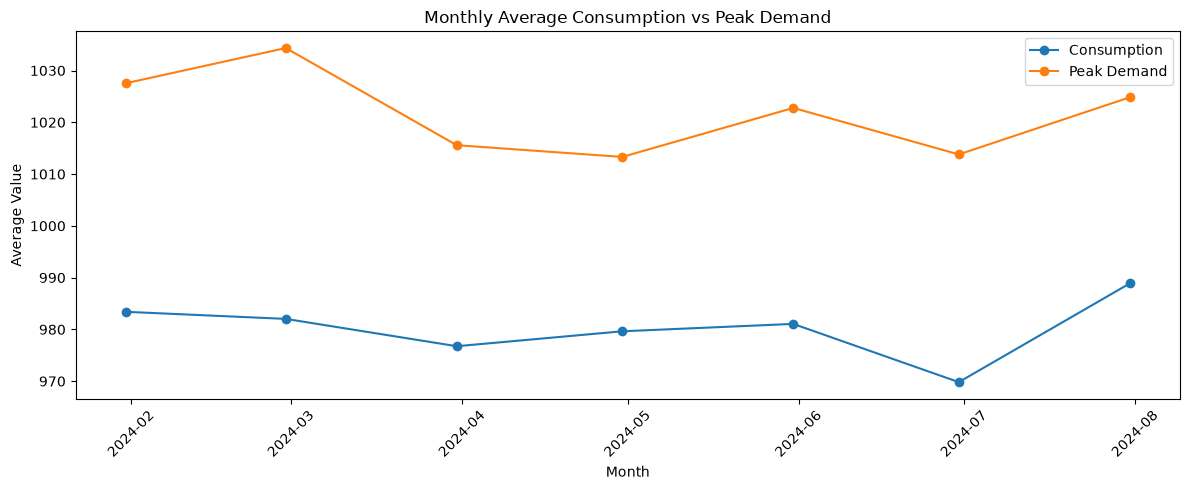

In [80]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_data.index,
    monthly_data["Consumption_MWh"],
    marker="o",
    label="Consumption"
)

plt.plot(
    monthly_data.index,
    monthly_data["Peak_Demand_MW"],
    marker="o",
    label="Peak Demand"
)

plt.title("Monthly Average Consumption vs Peak Demand")
plt.xlabel("Month")
plt.ylabel("Average Value")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Day-of-Week Pattern

In [81]:
df_ts["Day_Name"] = df_ts.index.day_name()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_data = df_ts.groupby("Day_Name")[[
    "Consumption_MWh",
    "Peak_Demand_MW"
]].mean().reindex(day_order)

weekly_data

,Consumption_MWh,Peak_Demand_MW
Day_Name,,
Monday,1004.653025,1048.403063
Tuesday,1040.993482,1066.035187
Wednesday,1006.982578,1040.409569
Thursday,1015.926840,1061.149472
Friday,1015.765567,1080.359684
Saturday,881.886085,922.880912
Sunday,888.695005,926.395338


Day-of-Week Bar Chart

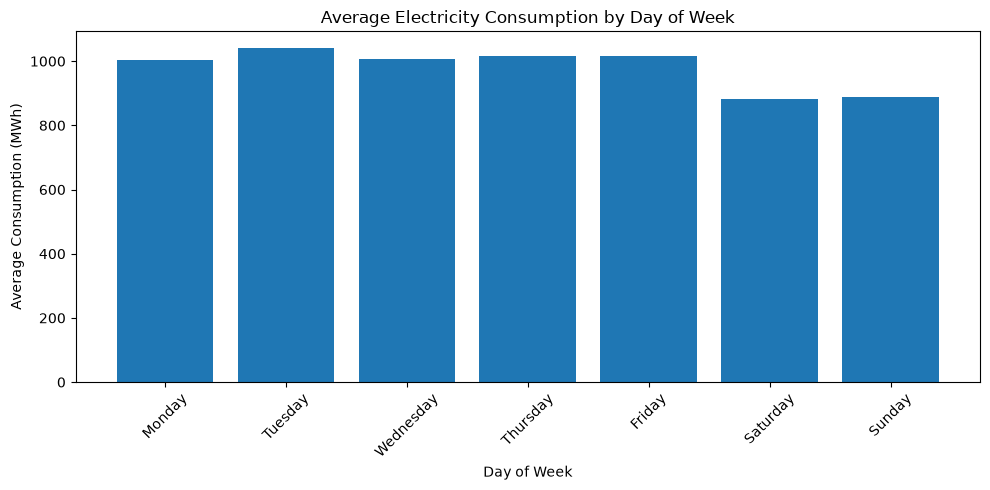

In [82]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekly_data.index,
    weekly_data["Consumption_MWh"]
)

plt.title("Average Electricity Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Consumption (MWh)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Day-of-Week Peak Demand

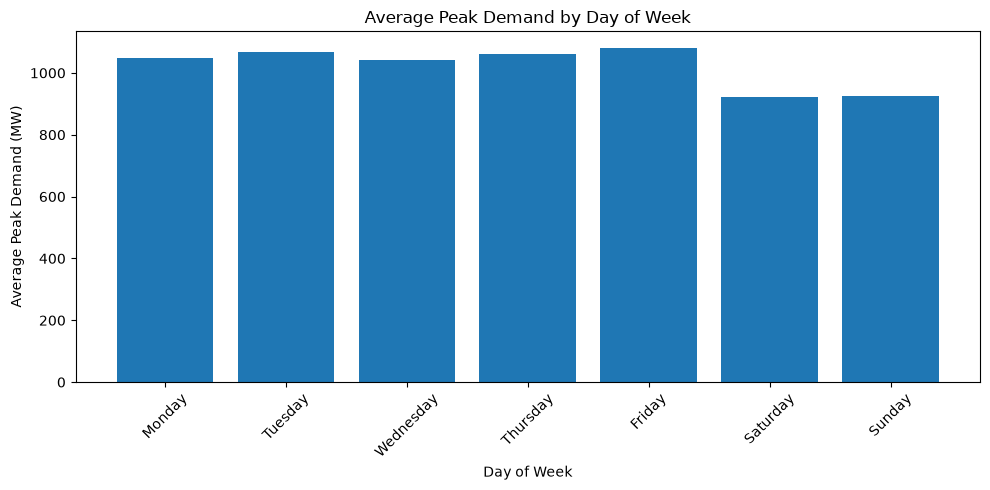

In [83]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekly_data.index,
    weekly_data["Peak_Demand_MW"]
)

plt.title("Average Peak Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Peak Demand (MW)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Rolling Average

In [84]:
daily_data["Consumption_7Day_MA"] = (
    daily_data["Consumption_MWh"]
    .rolling(window=7)
    .mean()
)

daily_data.head(10)

,Consumption_MWh,Peak_Demand_MW,Consumption_7Day_MA
Date_Time,,,
2024-01-01,987.953750,996.522083,NaN
2024-01-02,1092.538557,1164.275200,NaN
2024-01-03,1009.025417,1092.723750,NaN
2024-01-04,1035.547391,1078.490870,NaN
2024-01-05,1042.681667,1063.859583,NaN
2024-01-06,871.592609,881.610870,NaN
2024-01-07,863.720000,903.341304,986.151341
2024-01-08,1025.953750,1074.338333,991.579913
2024-01-09,1019.775833,1087.812500,981.185238


Actual vs 7-Day Moving Average

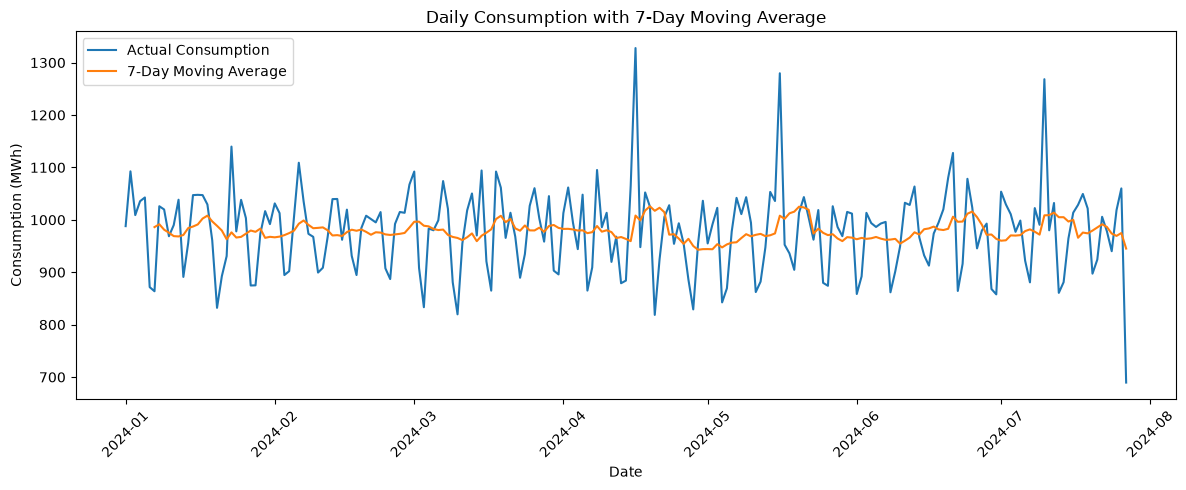

In [85]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_data.index,
    daily_data["Consumption_MWh"],
    label="Actual Consumption"
)

plt.plot(
    daily_data.index,
    daily_data["Consumption_7Day_MA"],
    label="7-Day Moving Average"
)

plt.title("Daily Consumption with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Consumption (MWh)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Peak Demand 7-Day Moving Average

In [86]:
daily_data["Peak_Demand_7Day_MA"] = (
    daily_data["Peak_Demand_MW"]
    .rolling(window=7)
    .mean()
)

daily_data.head(10)

,Consumption_MWh,Peak_Demand_MW,Consumption_7Day_MA,Peak_Demand_7Day_MA
Date_Time,,,,
2024-01-01,987.953750,996.522083,NaN,NaN
2024-01-02,1092.538557,1164.275200,NaN,NaN
2024-01-03,1009.025417,1092.723750,NaN,NaN
2024-01-04,1035.547391,1078.490870,NaN,NaN
2024-01-05,1042.681667,1063.859583,NaN,NaN
2024-01-06,871.592609,881.610870,NaN,NaN
2024-01-07,863.720000,903.341304,986.151341,1025.831951
2024-01-08,1025.953750,1074.338333,991.579913,1036.948559
2024-01-09,1019.775833,1087.812500,981.185238,1026.025316


Actual vs 7-Day Peak Demand Moving Average

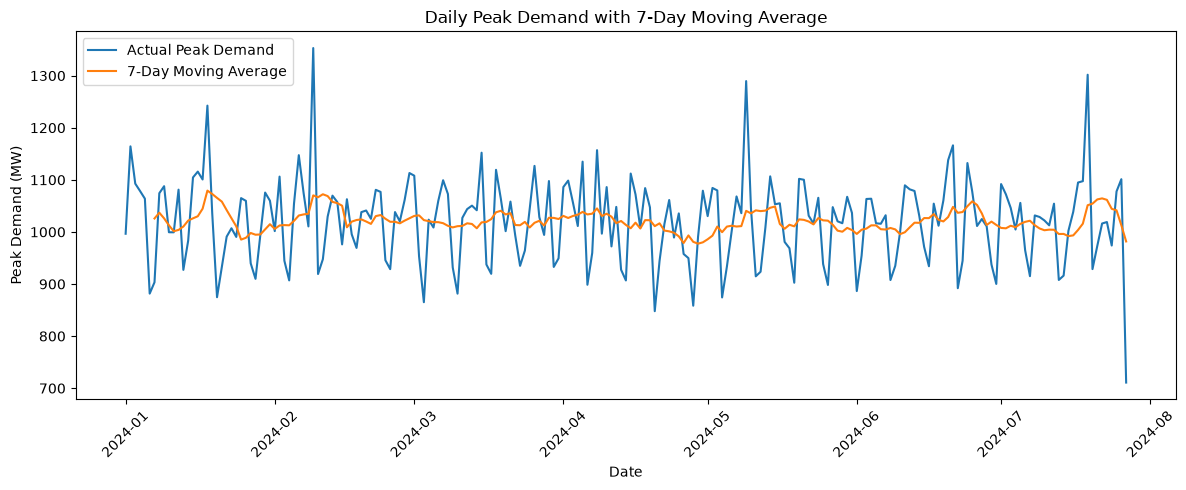

In [87]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_data.index,
    daily_data["Peak_Demand_MW"],
    label="Actual Peak Demand"
)

plt.plot(
    daily_data.index,
    daily_data["Peak_Demand_7Day_MA"],
    label="7-Day Moving Average"
)

plt.title("Daily Peak Demand with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Peak Demand (MW)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Seasonality Check


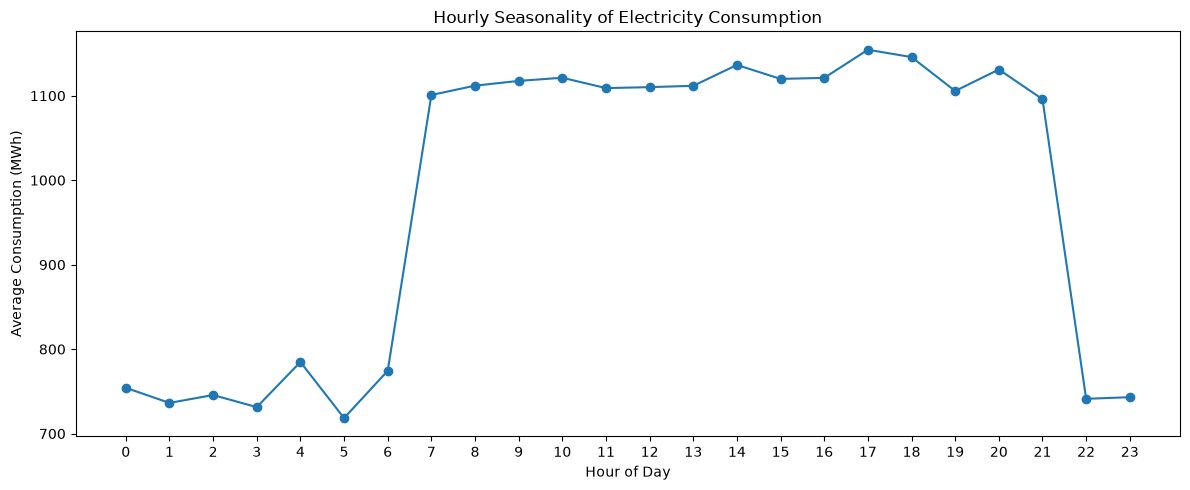

In [88]:
hourly_data["Consumption_MWh"].plot(
    figsize=(12, 5),
    marker="o"
)

plt.title("Hourly Seasonality of Electricity Consumption")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (MWh)")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

Rendu groups-oda mean Consumption

In [89]:
peak_groups = df_clean.groupby("Peak_Flag")["Consumption_MWh"].mean()

peak_groups

Peak_Flag
No      907.413805
Yes    1392.147797
Name: Consumption_MWh, dtype: float64

Mean Difference

In [90]:
mean_difference = (
    peak_groups["Yes"] - peak_groups["No"]
)

mean_difference

np.float64(484.7339918795958)

Independent T-Test

In [91]:
from scipy.stats import ttest_ind

groups create

In [92]:
peak = df_clean[
    df_clean["Peak_Flag"] == "Yes"
]["Consumption_MWh"]

non_peak = df_clean[
    df_clean["Peak_Flag"] == "No"
]["Consumption_MWh"]

In [93]:
t_stat, p_value = ttest_ind(
    peak,
    non_peak,
    equal_var=False
)

t_stat, p_value

(np.float64(63.67779007632824), np.float64(0.0))

Result-a clean-ah store

In [94]:
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Significant difference exists.")
else:
    print("Fail to reject H0: No significant difference.")

T-statistic: 63.67779007632824
P-value: 0.0
Reject H0: Significant difference exists.


95% Confidence Interval

In [95]:
import numpy as np

mean_peak = peak.mean()
mean_non_peak = non_peak.mean()

diff = mean_peak - mean_non_peak

n1 = len(peak)
n2 = len(non_peak)

var1 = peak.var()
var2 = non_peak.var()

se = np.sqrt((var1 / n1) + (var2 / n2))

df_welch = (
    ((var1 / n1) + (var2 / n2)) ** 2
    /
    (
        ((var1 / n1) ** 2 / (n1 - 1))
        +
        ((var2 / n2) ** 2 / (n2 - 1))
    )
)

from scipy.stats import t

critical_value = t.ppf(0.975, df_welch)

lower = diff - critical_value * se
upper = diff + critical_value * se

lower, upper

(np.float64(469.80329183561264), np.float64(499.66469192357897))

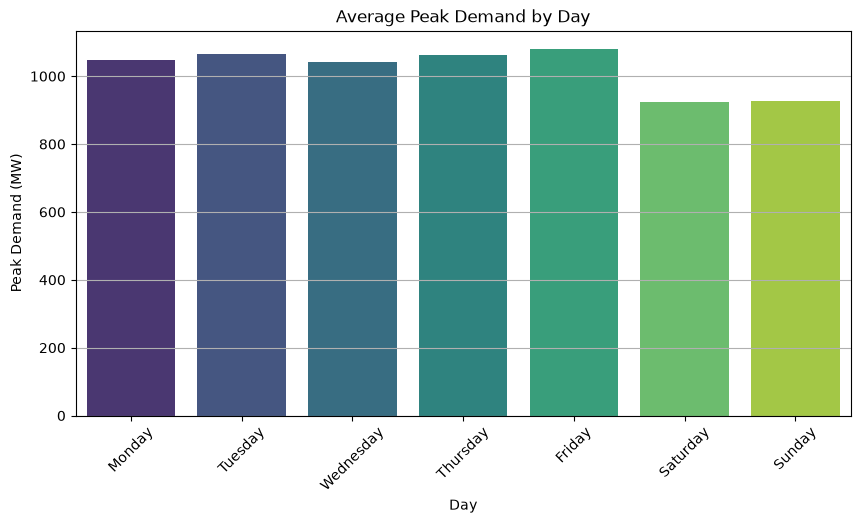

In [104]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekly_data.reset_index(),
    x="Day_Name",
    y="Peak_Demand_MW",
    hue="Day_Name",
    palette="viridis",
    legend=False
)

plt.title("Average Peak Demand by Day")
plt.xlabel("Day")
plt.ylabel("Peak Demand (MW)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()


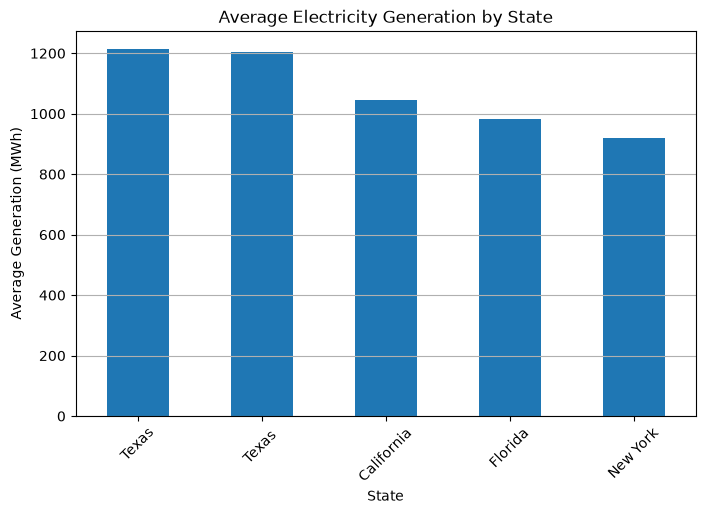

In [105]:
state_generation = df_clean.groupby("State")["Generation_MWh"].mean().sort_values(ascending=False)

state_generation.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Electricity Generation by State")
plt.xlabel("State")
plt.ylabel("Average Generation (MWh)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()